In [1]:
import warnings
from matplotlib.backends.backend_pdf import PdfPages
from src.sgtlib.utils.sgt_utils import sgt_excel_to_dataframe, sgt_spider_plot, sgt_scaling_plot

warnings.filterwarnings("ignore", category=RuntimeWarning)
## Uncomment to install Libraries (if not installed)
#!pip3 install openpyxl

In [5]:
# Read the Excel files and save in one DataFrame
allowed_ext = ".xlsx"
excel_dir_path = "n_10/"
pdf_file = "n_10/scaling_results-10.pdf"
plt_figs = []

# all_sheets = pd.read_excel('n_10/AllData.xlsx', sheet_name=None)
all_sheets = sgt_excel_to_dataframe(excel_dir_path, allowed_ext)

In [6]:
# Filter the relevant materials and parameters
materials = ['BSE 017', 'BSE 011', 'BSE 024', 'BSE 025']
material_names = ['PAN/CGO', 'Carb. PAN', 'PAN', 'Carb. PAN/CGO']
parameters = ['Nodes', 'Edges', 'AD', 'Diameter', 'GD', 'BC', 'CC', 'EC']

material_labels = {key: name for (name, key) in zip(material_names, materials)}

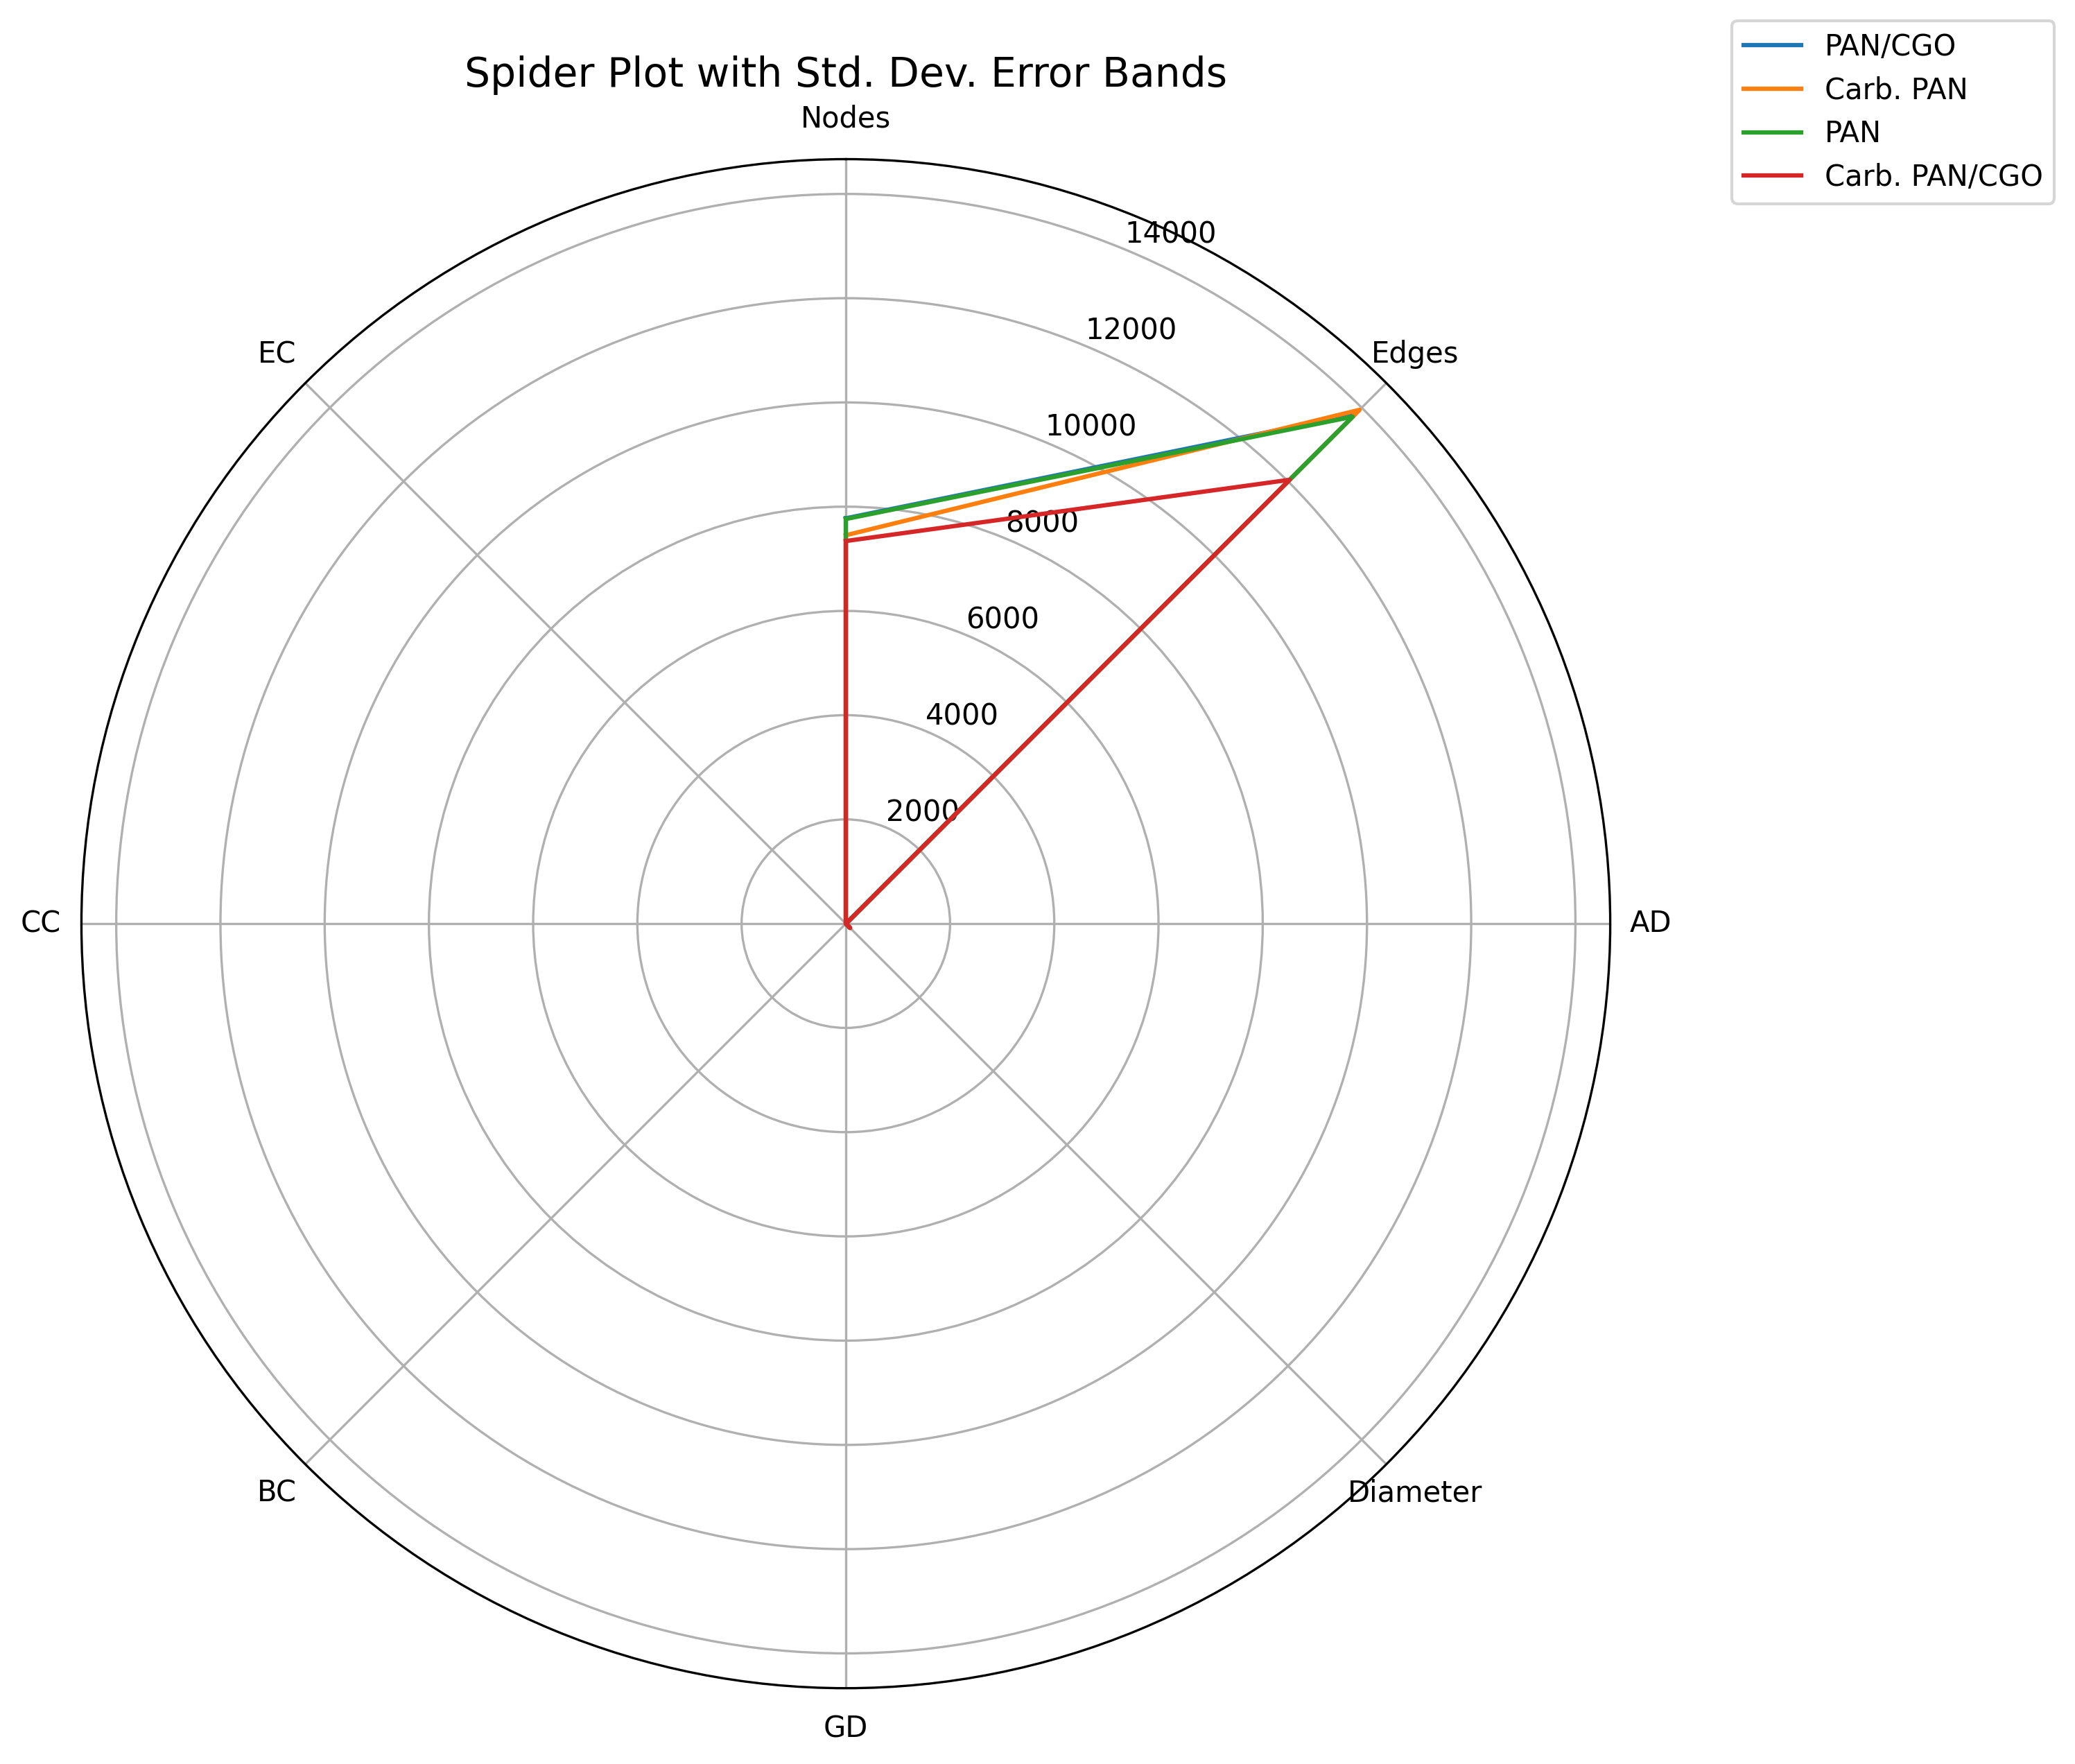

In [4]:
"""
Spider Plot
"""
df_sgt = all_sheets['SGT Descriptors']
plt_fig = sgt_spider_plot(df_sgt, material_labels, parameters)
plt_figs.append(plt_fig)

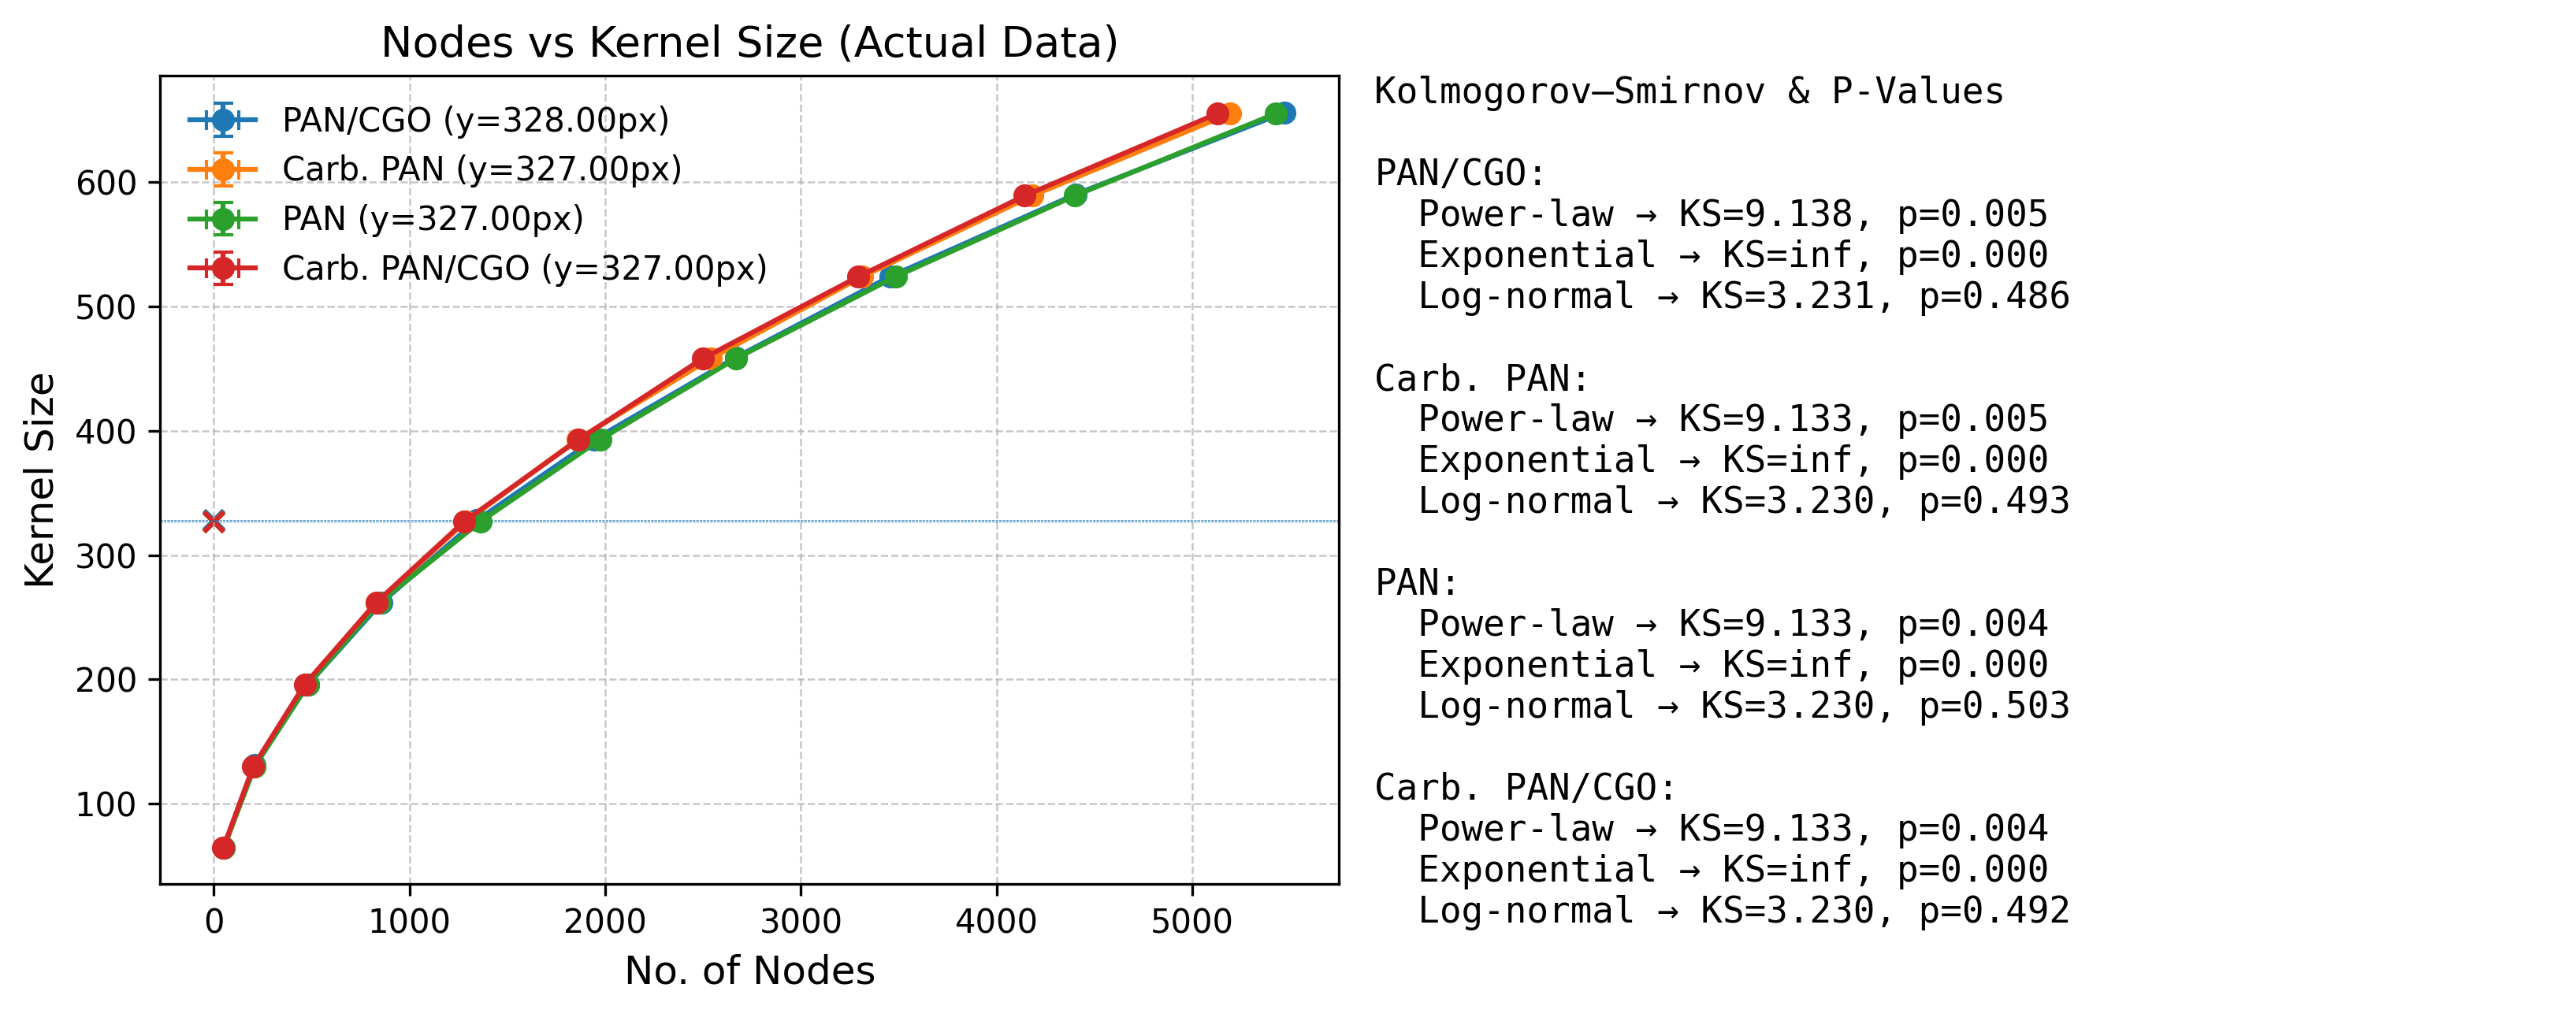

In [7]:
"""
Kernel Size vs Nodes
"""
df_kernel = all_sheets['Nodes-Kernel Size']
plt_fig = sgt_scaling_plot("Kernel Size", df_kernel, material_labels, skip_test=False)
plt_figs.append(plt_fig)


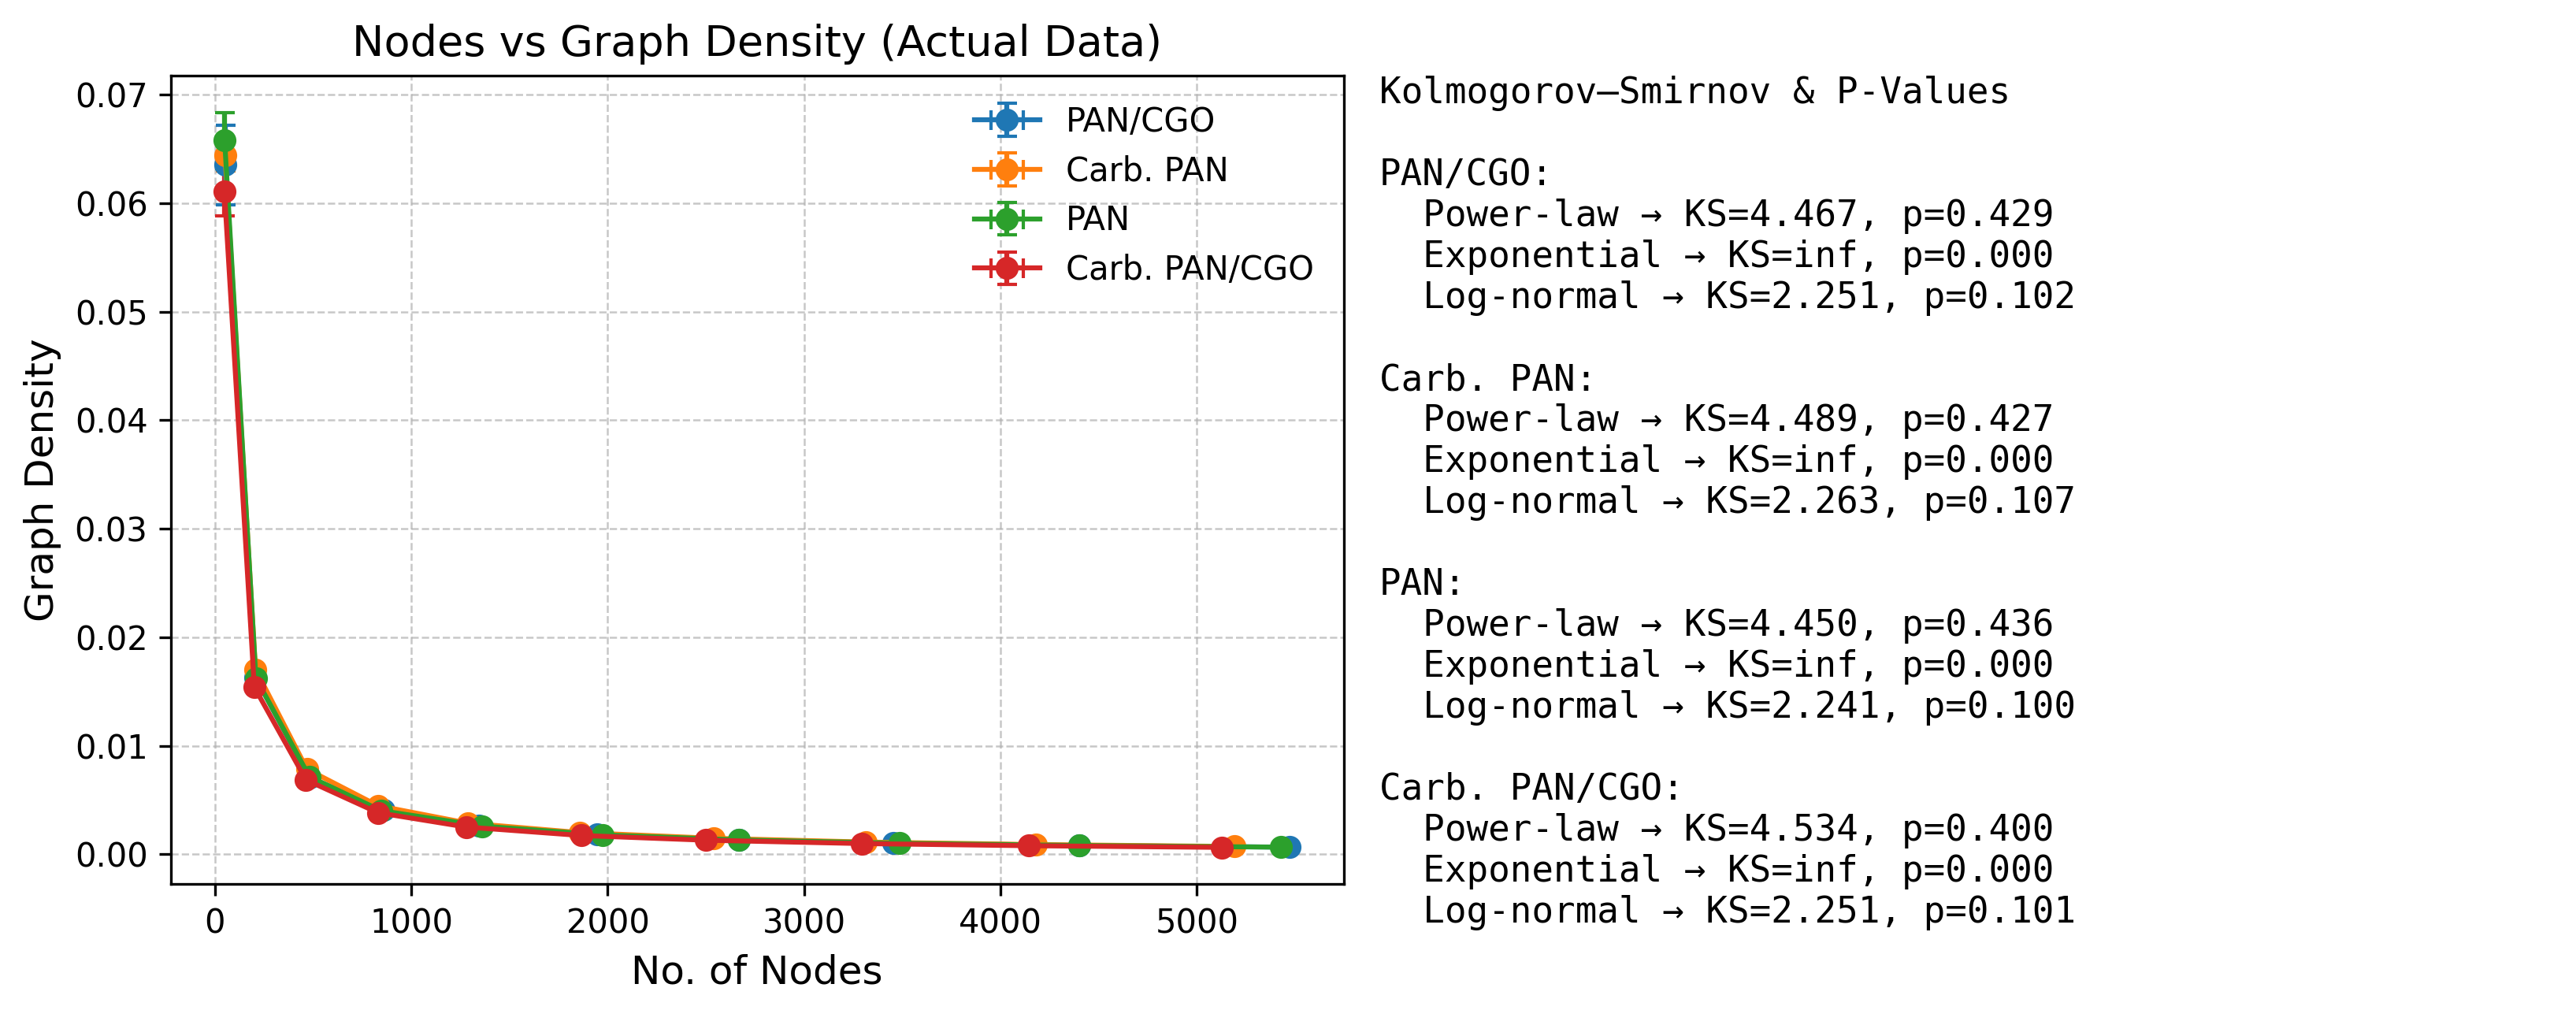

In [6]:
"""
Graph Density
"""
df_dens = all_sheets['Nodes-Density']
plt_fig = sgt_scaling_plot("Graph Density", df_dens, material_labels)
plt_figs.append(plt_fig)

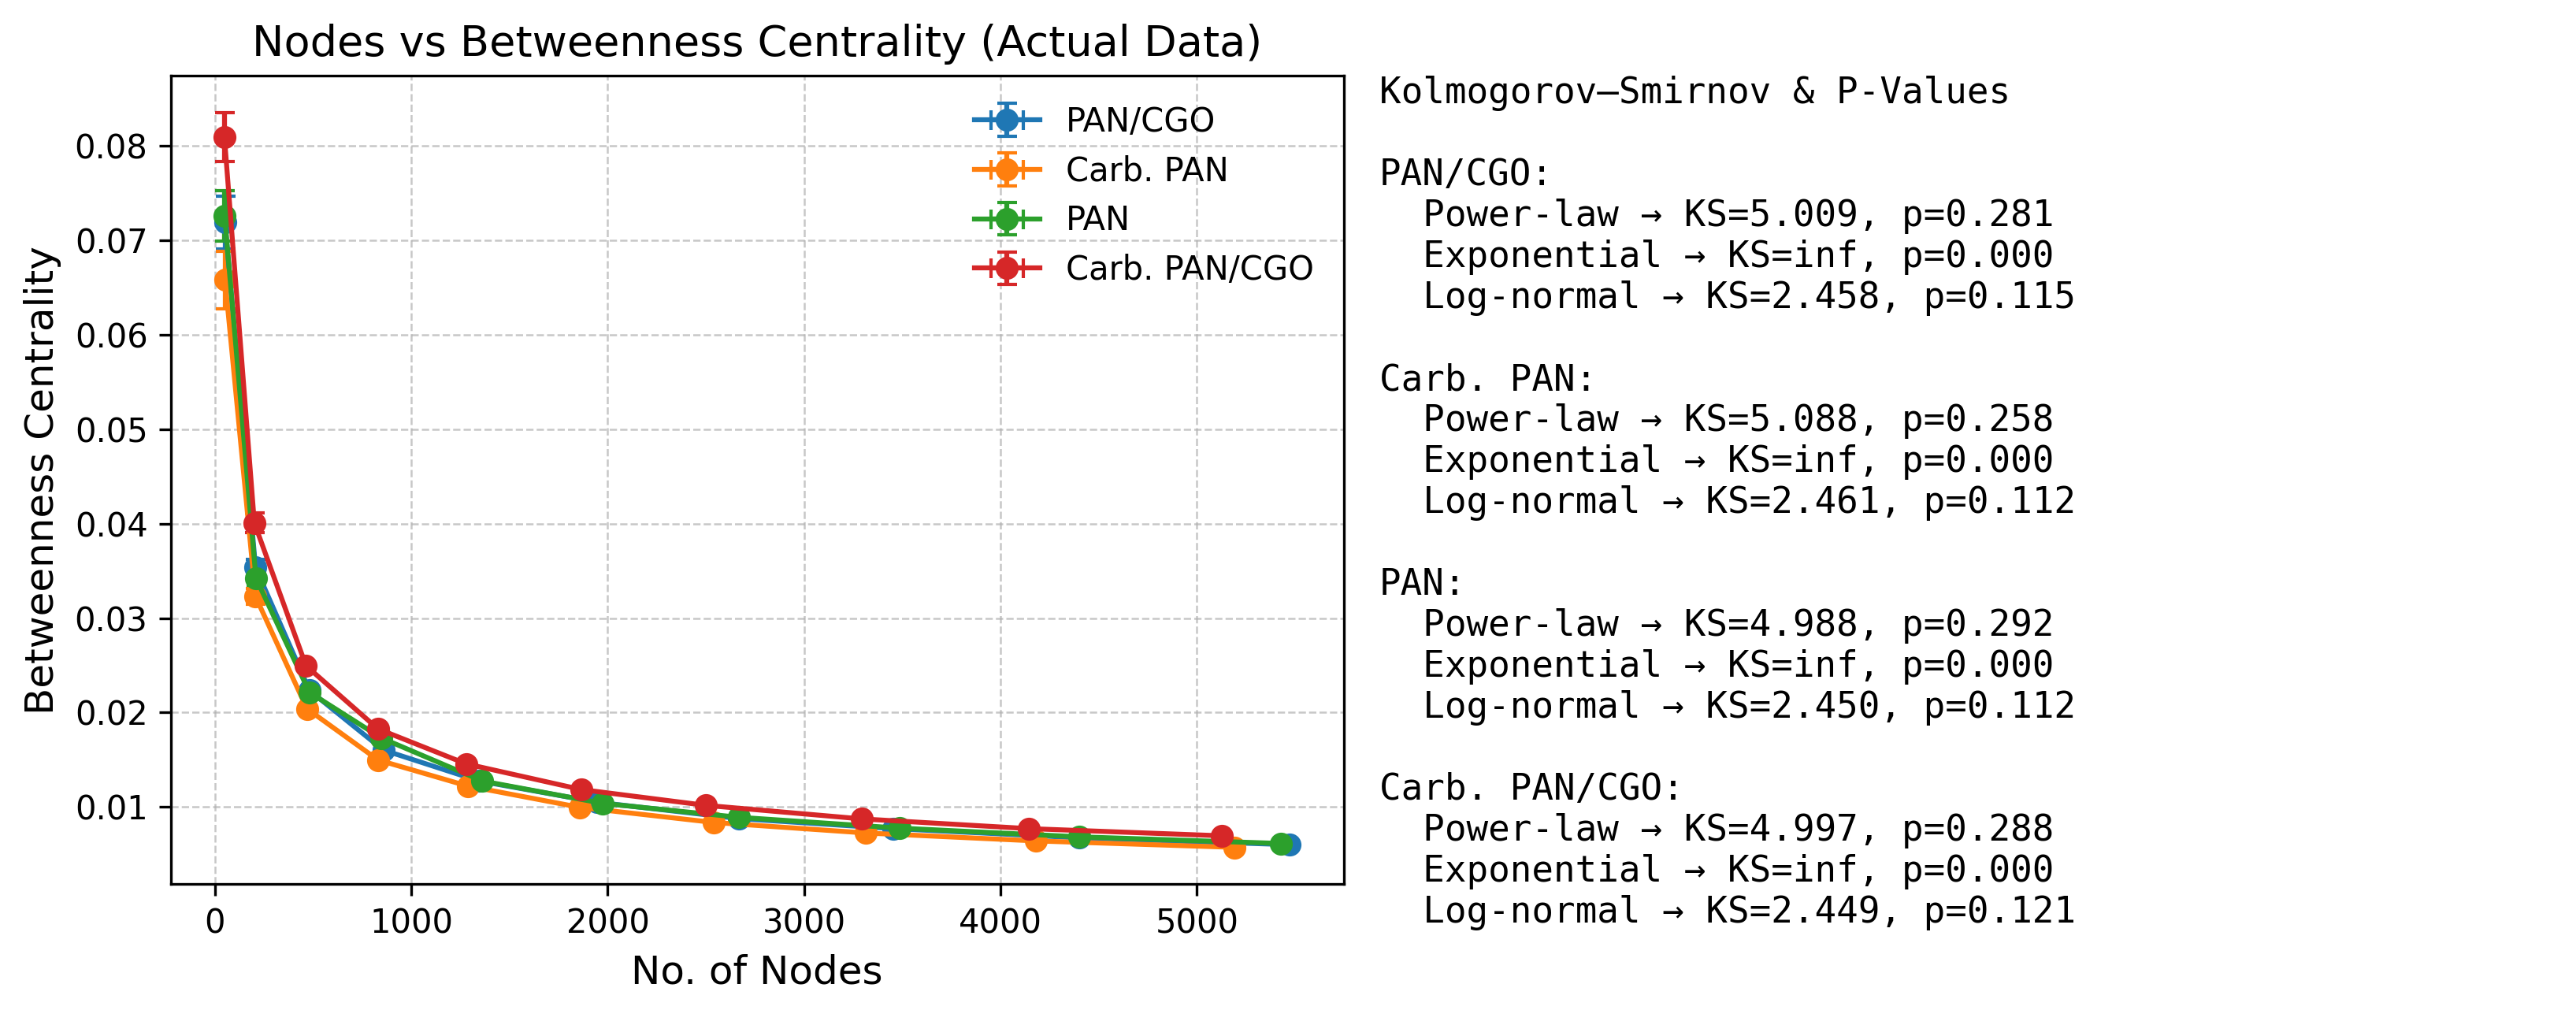

In [7]:
"""
Betweenness
"""
df_bet = all_sheets['Nodes-BC']
plt_fig = sgt_scaling_plot("Betweenness Centrality", df_bet, material_labels)
plt_figs.append(plt_fig)

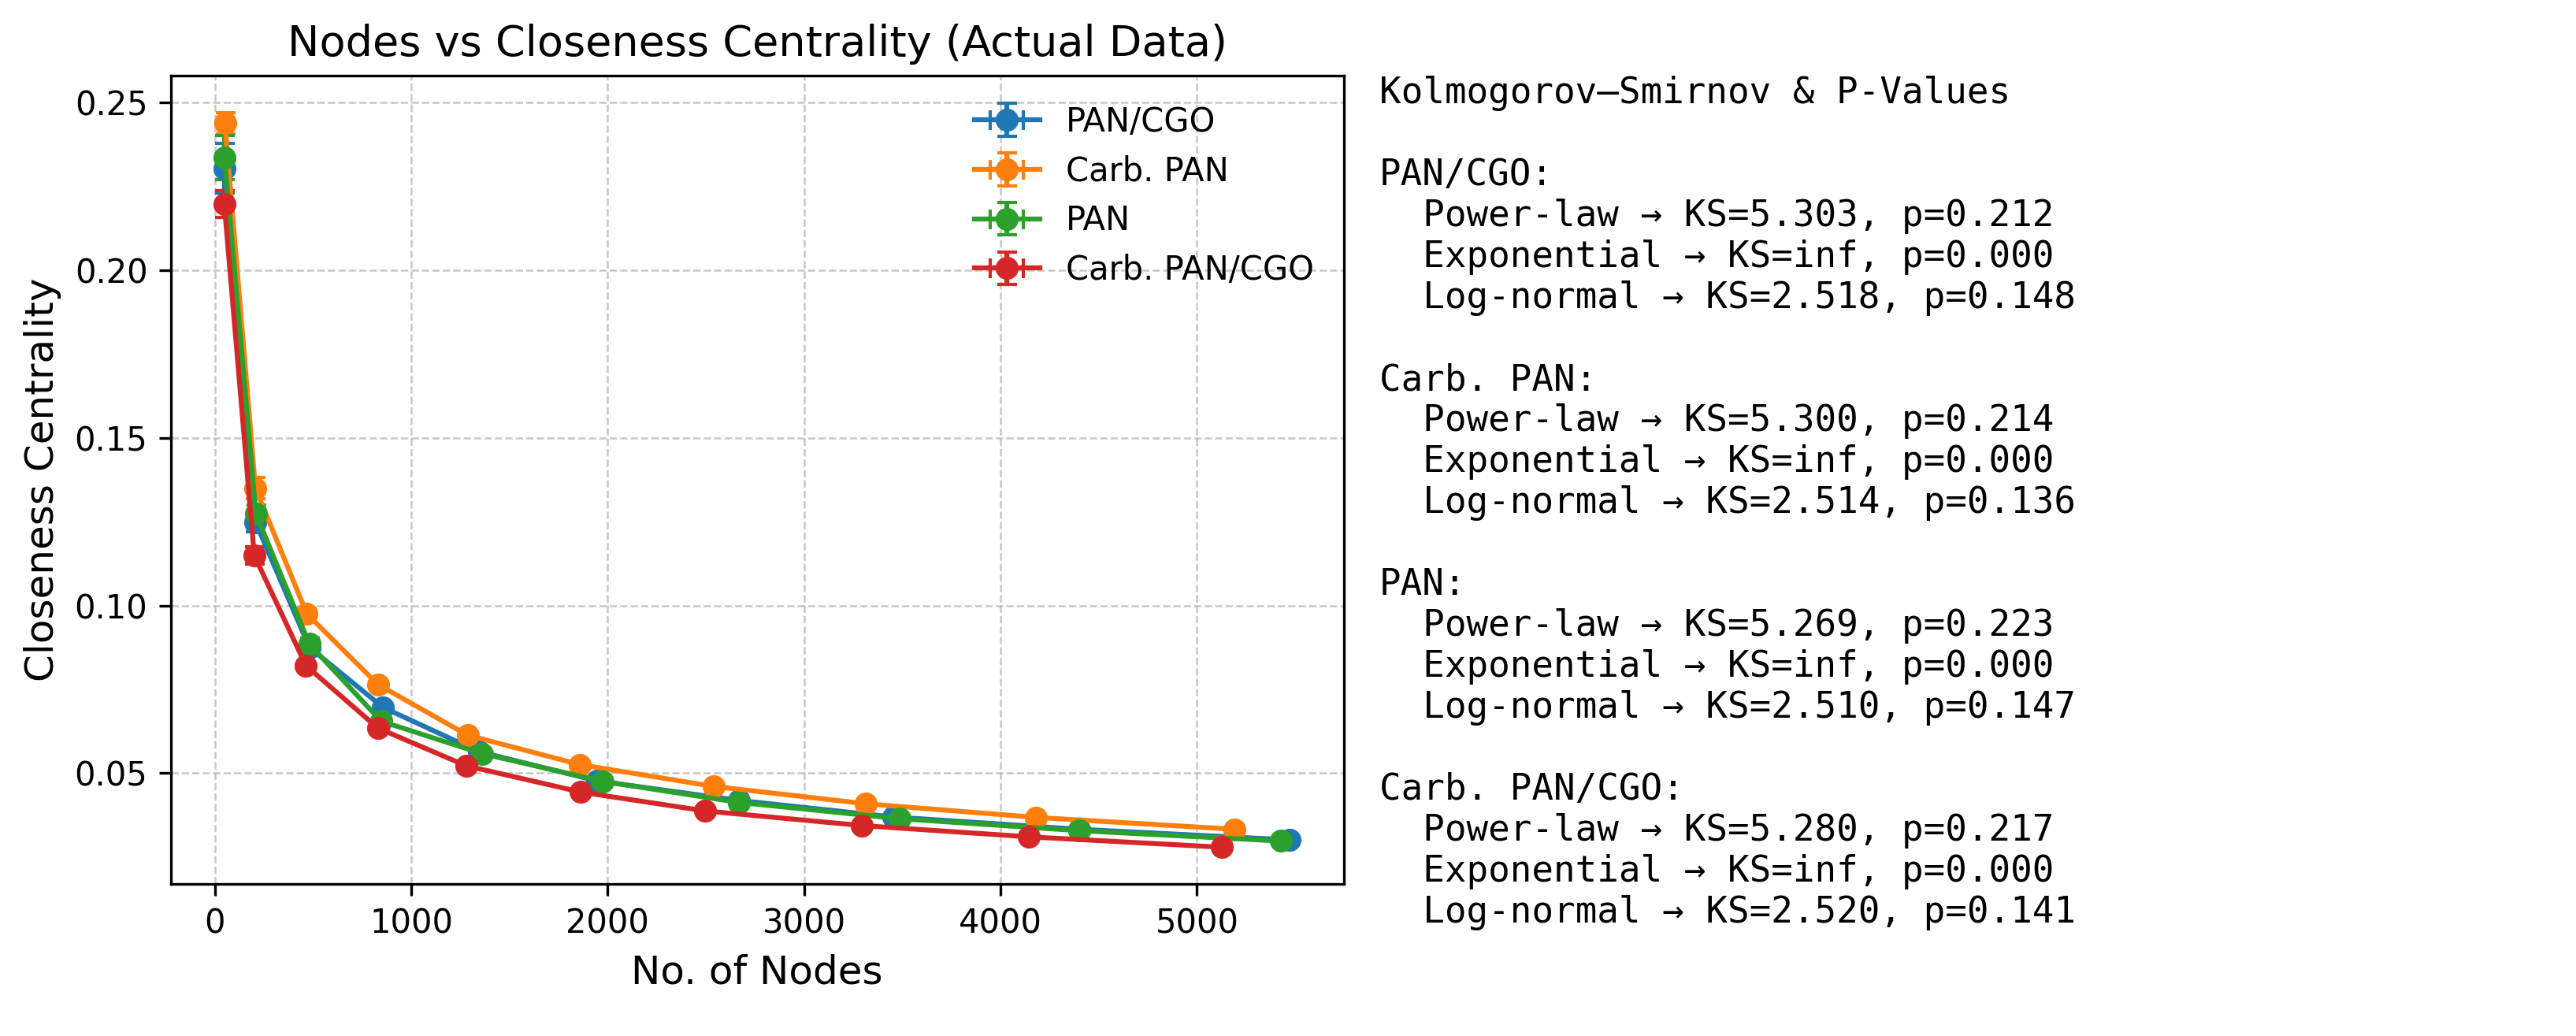

In [8]:
"""
Closeness
"""
df_clo = all_sheets['Nodes-CC']
plt_fig = sgt_scaling_plot("Closeness Centrality", df_clo, material_labels)
plt_figs.append(plt_fig)

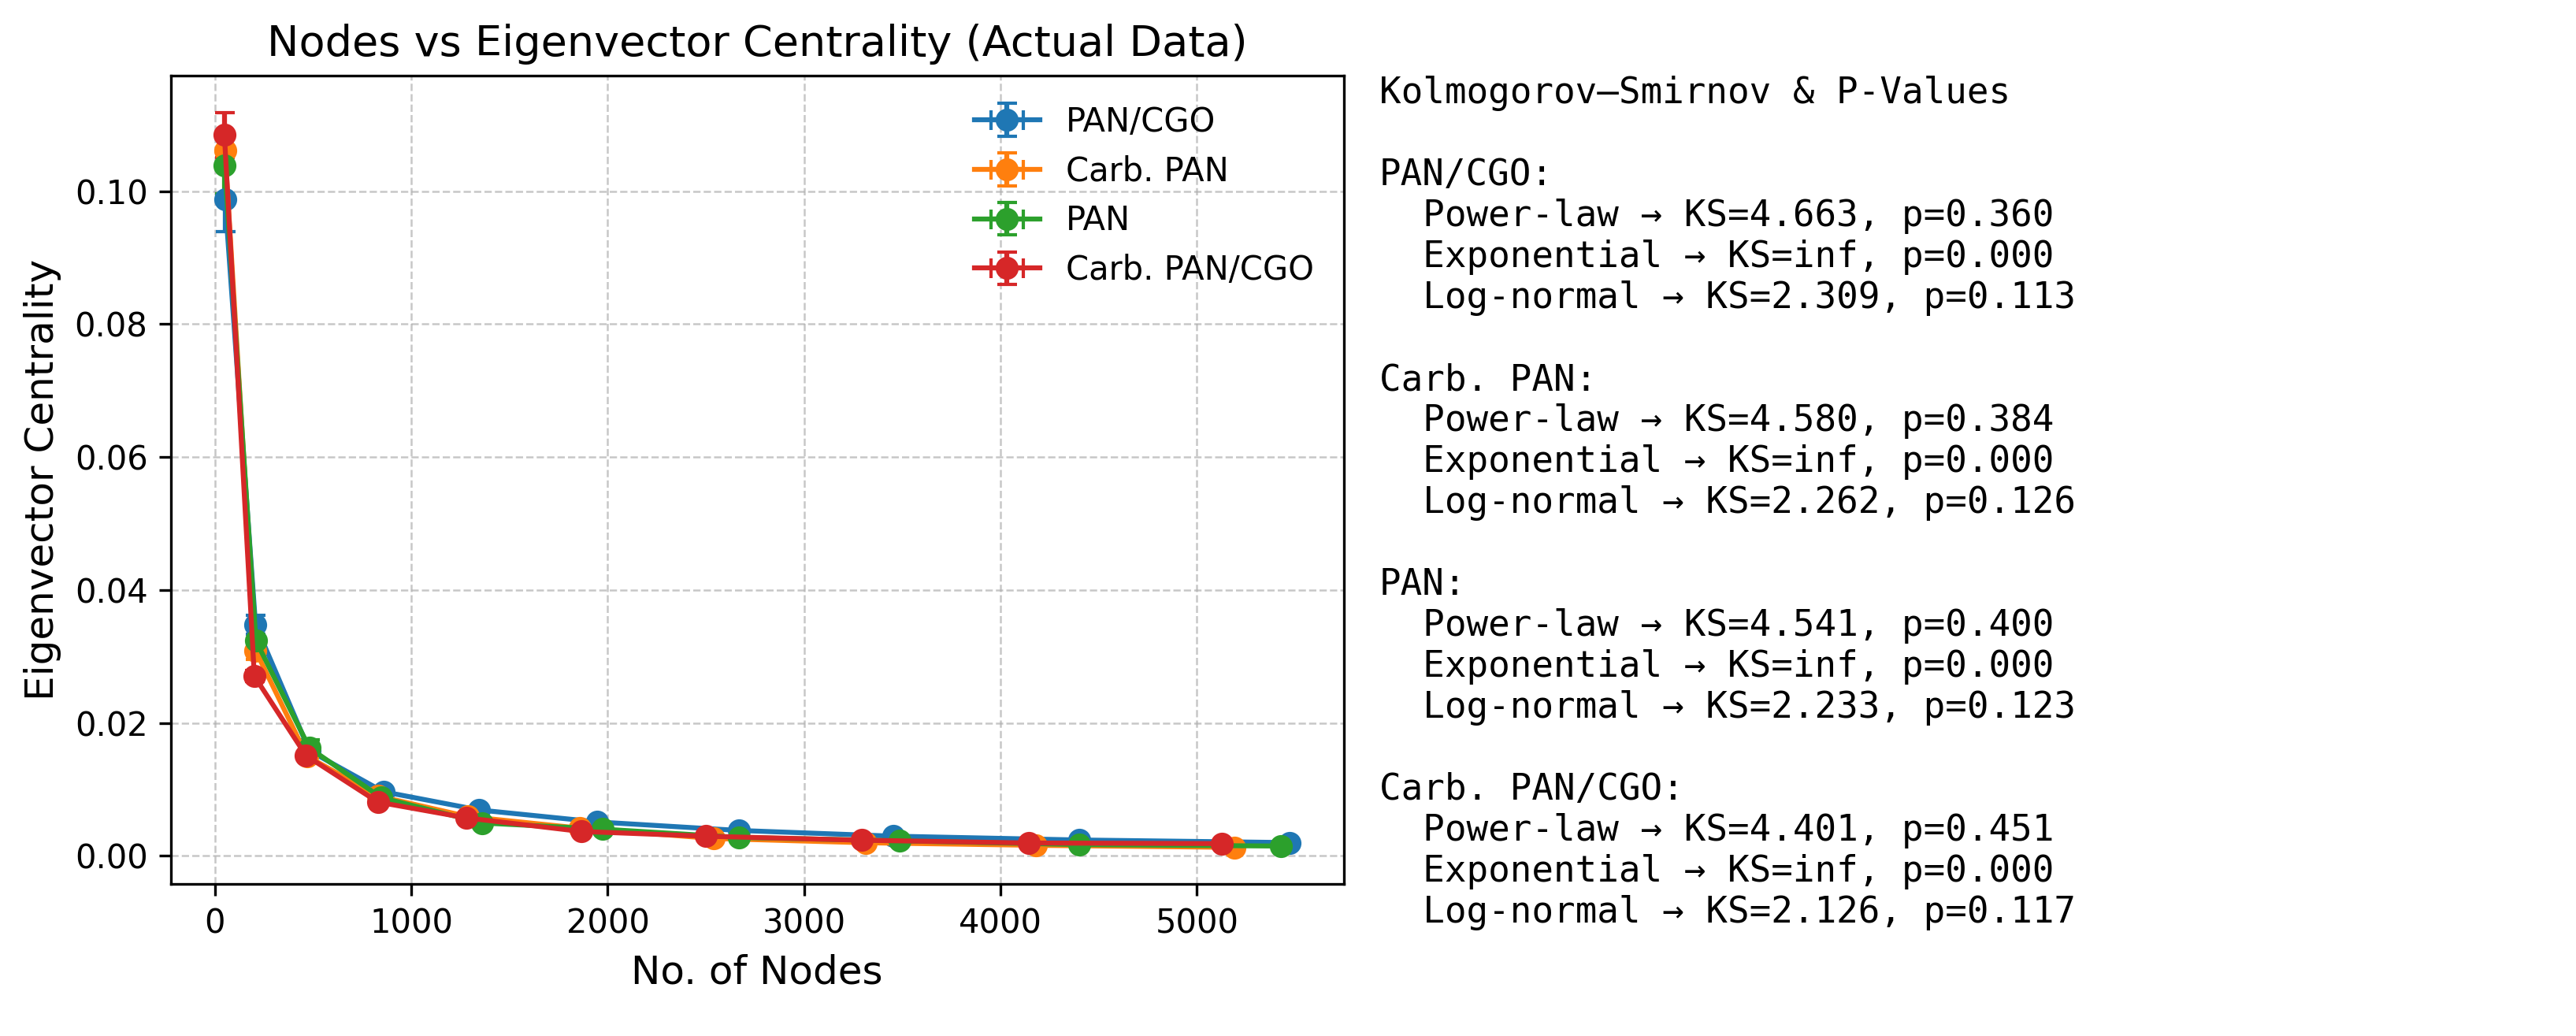

In [9]:
"""
Eigenvector
"""
df_eig = all_sheets['Nodes-EC']
plt_fig = sgt_scaling_plot("Eigenvector Centrality", df_eig, material_labels)
plt_figs.append(plt_fig)

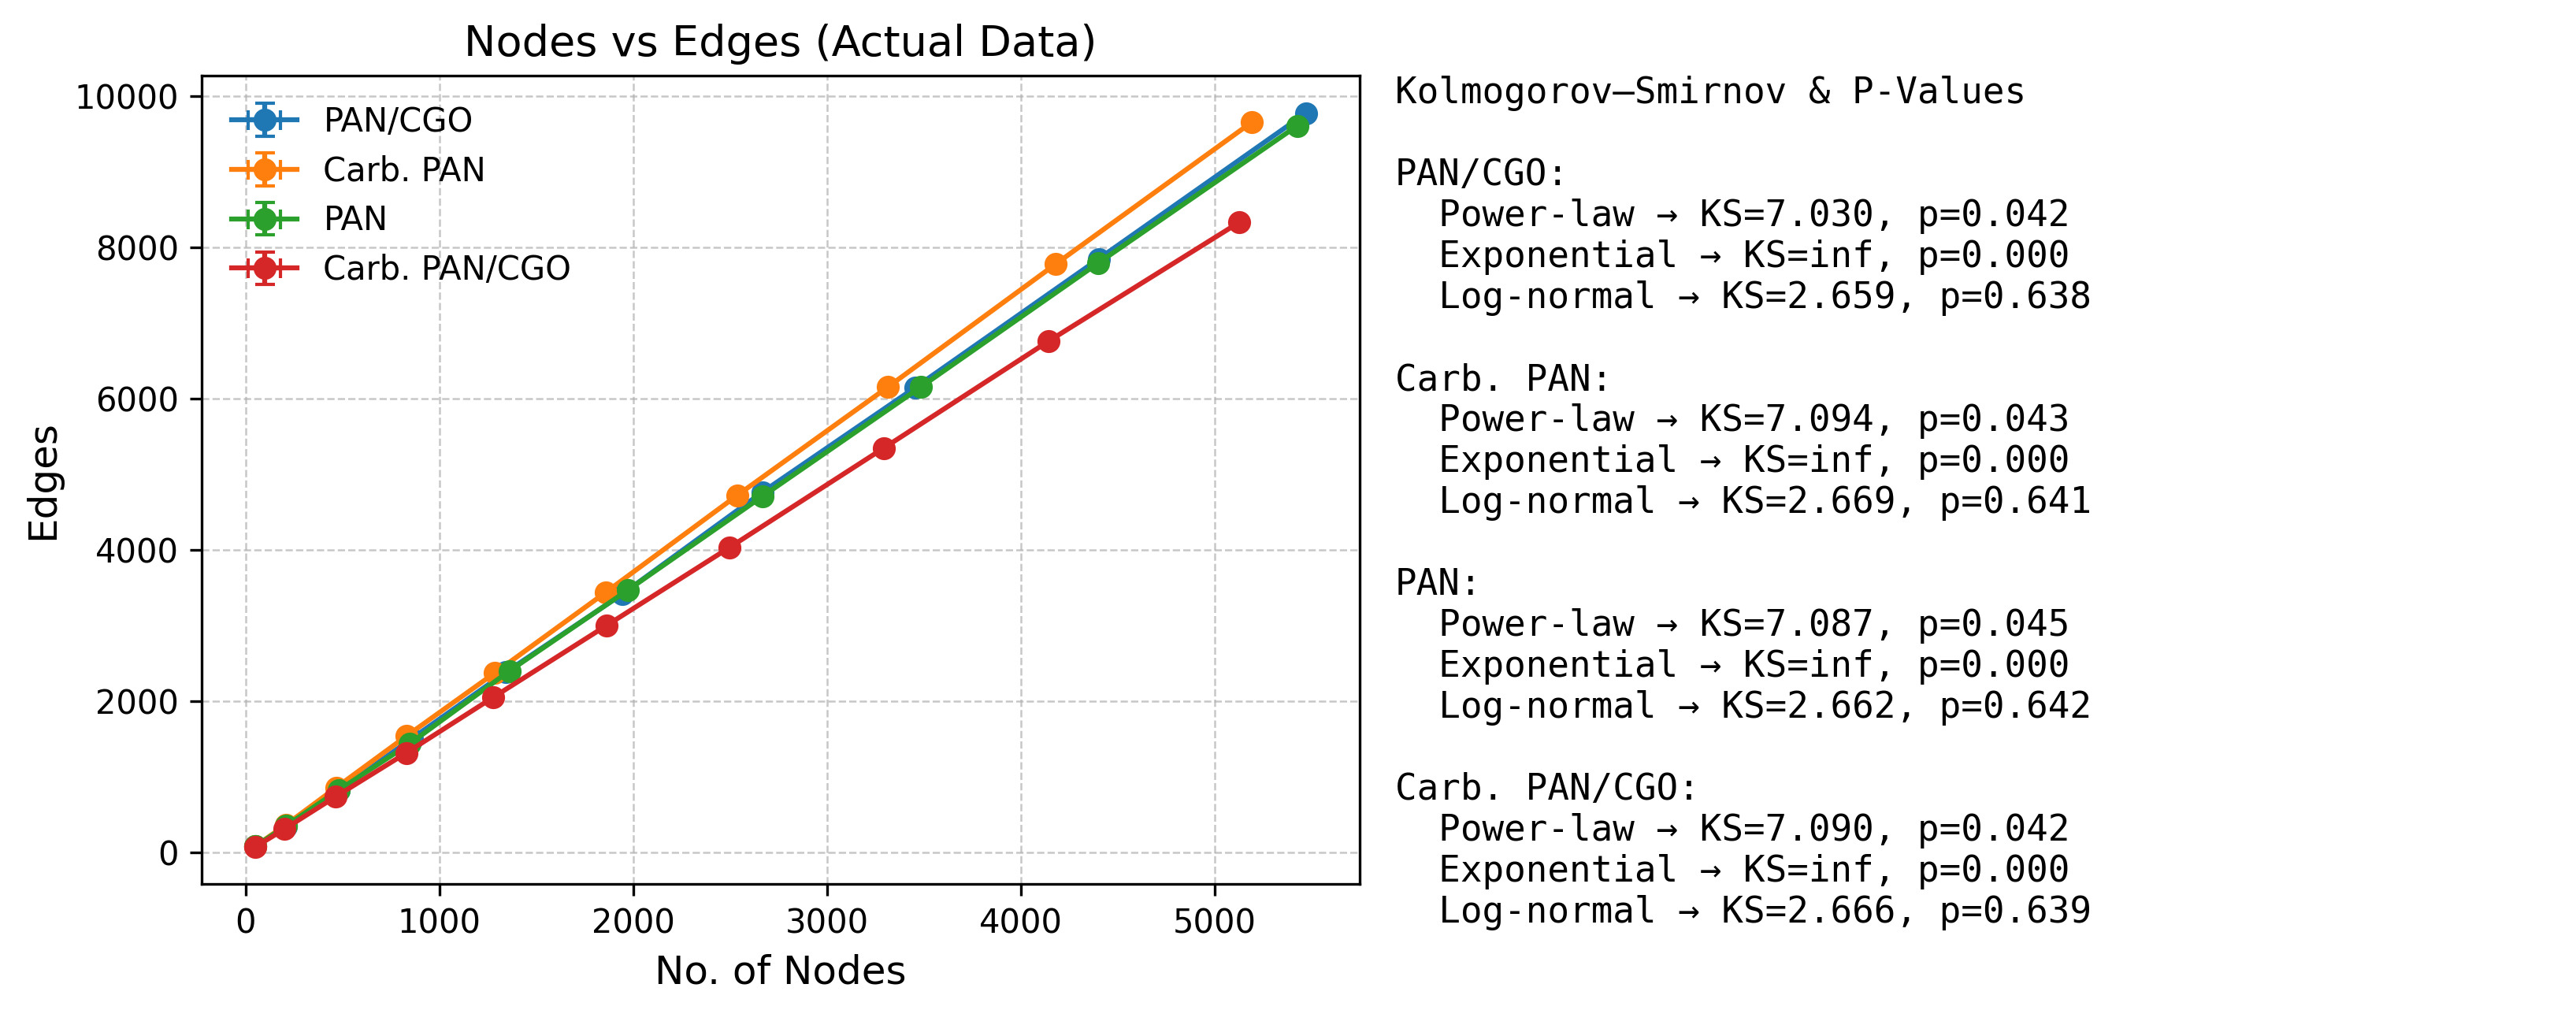

In [10]:
"""
No. Edges
"""
df_edges = all_sheets['Nodes-Edges']
plt_fig = sgt_scaling_plot("Edges", df_edges, material_labels, skip_test=False)
plt_figs.append(plt_fig)

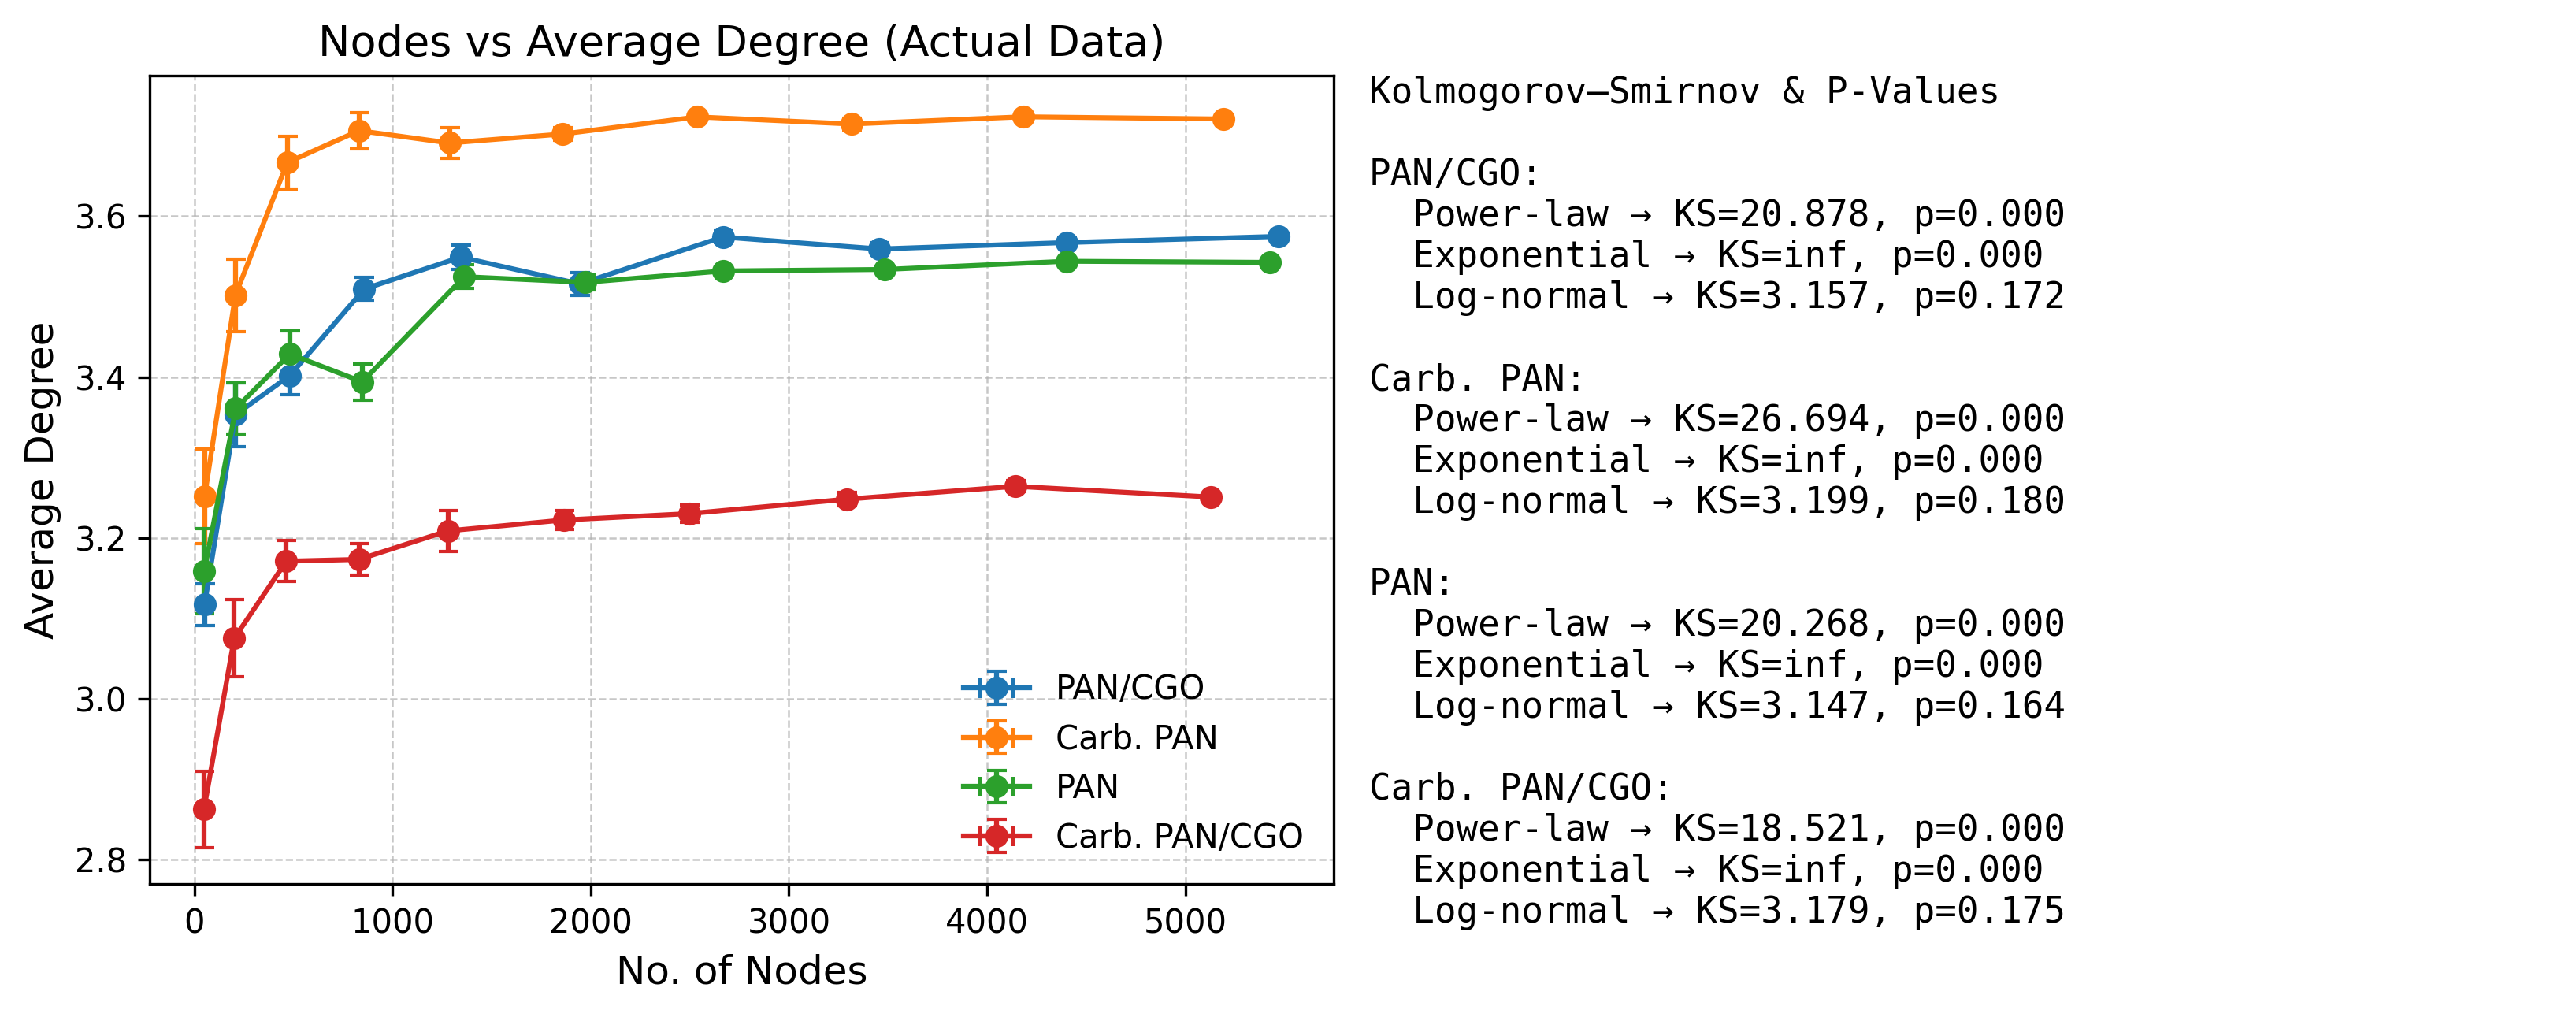

In [11]:
"""
Average Degree
"""
df_deg = all_sheets['Nodes-Degree']
plt_fig = sgt_scaling_plot("Average Degree", df_deg, material_labels, skip_test=False)
plt_figs.append(plt_fig)

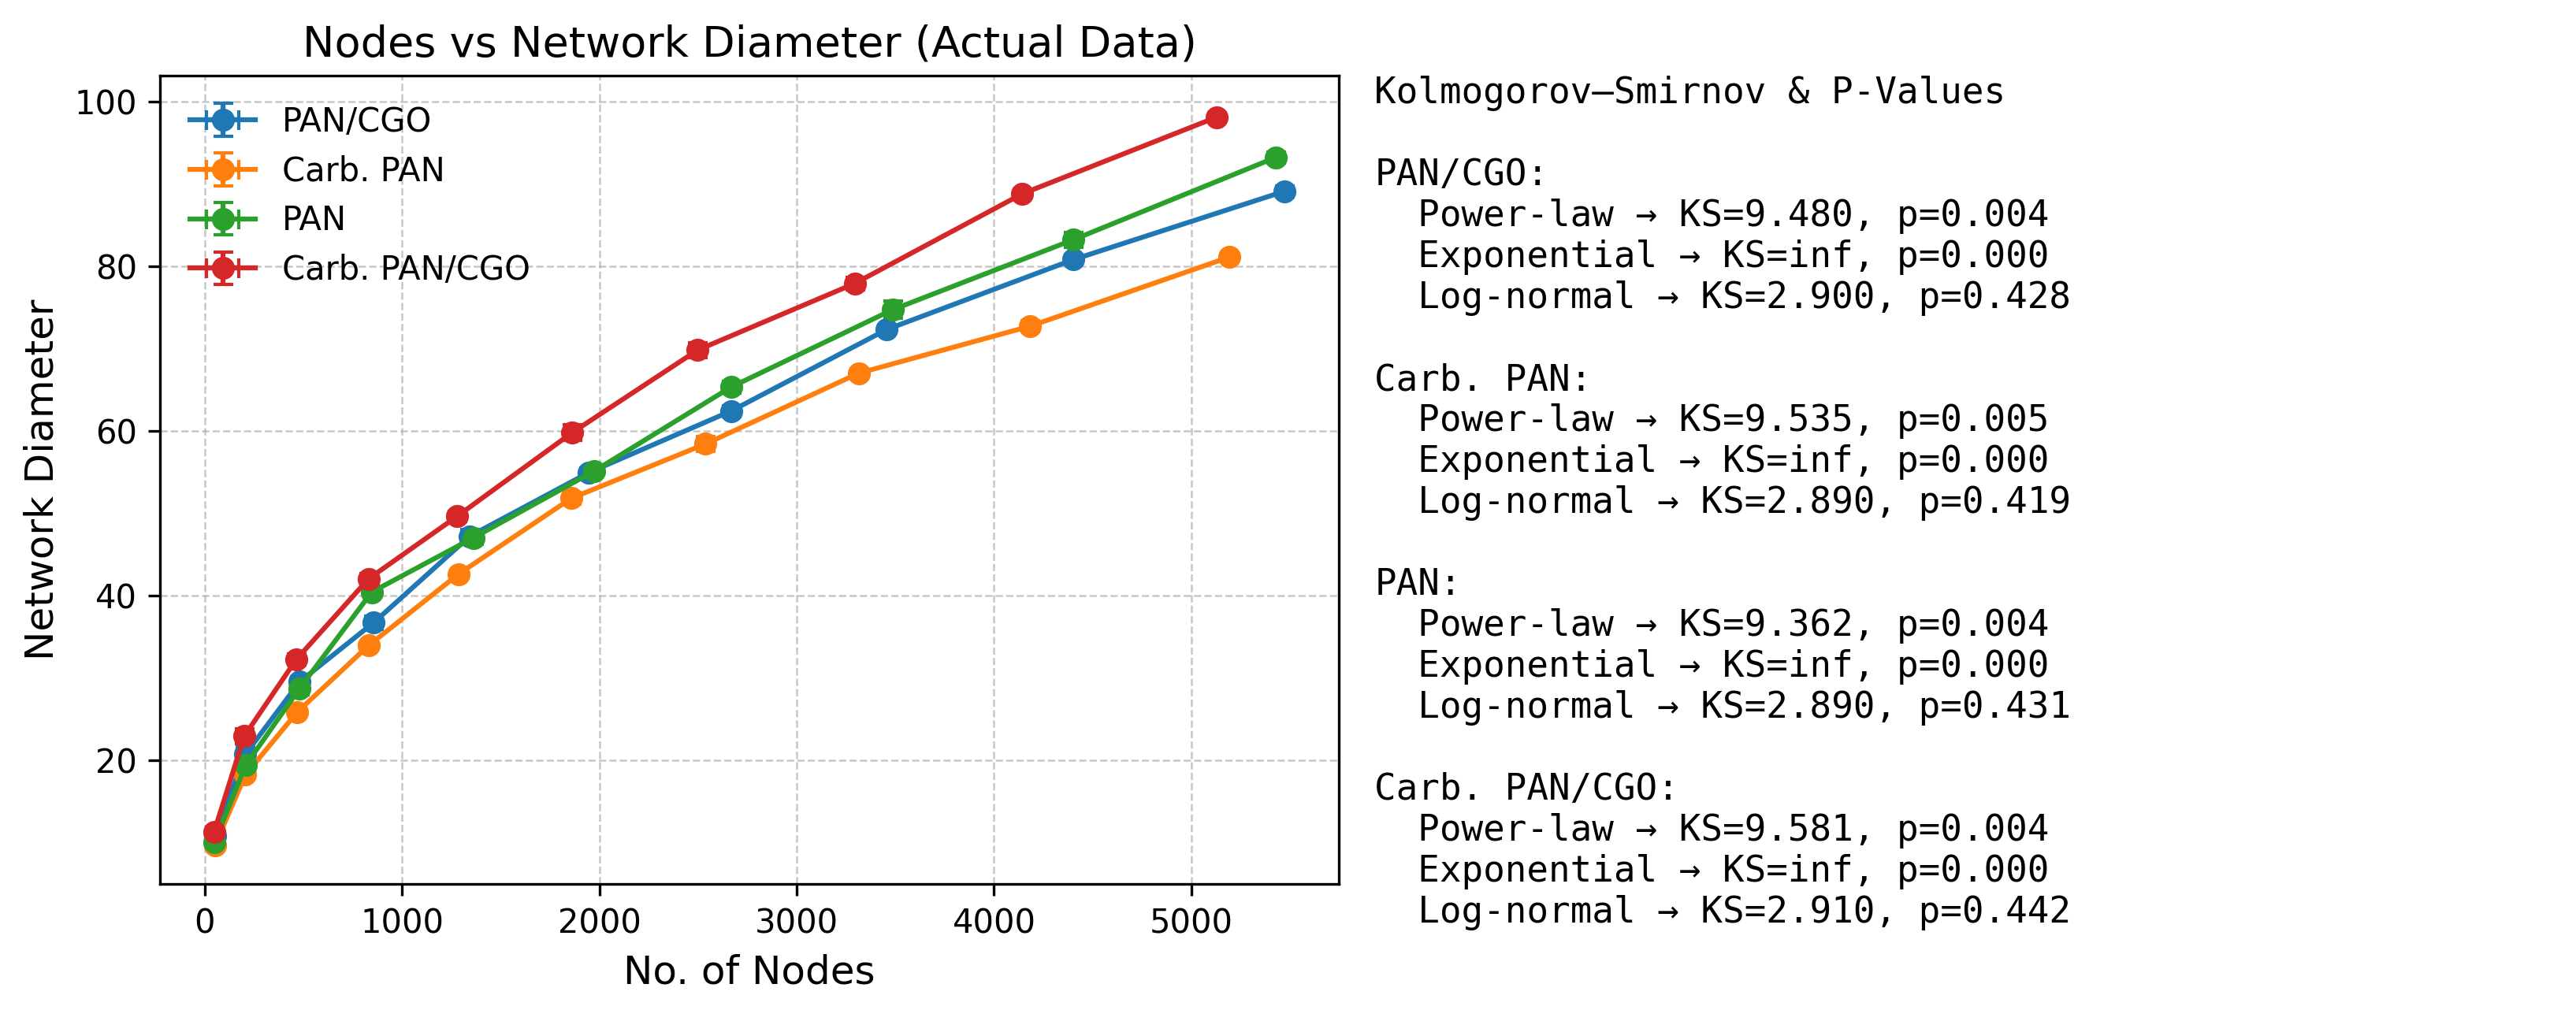

In [12]:
"""
Network Diameter
"""
df_dia = all_sheets['Nodes-Diameter']
plt_fig = sgt_scaling_plot("Network Diameter", df_dia, material_labels, skip_test=False)
plt_figs.append(plt_fig)

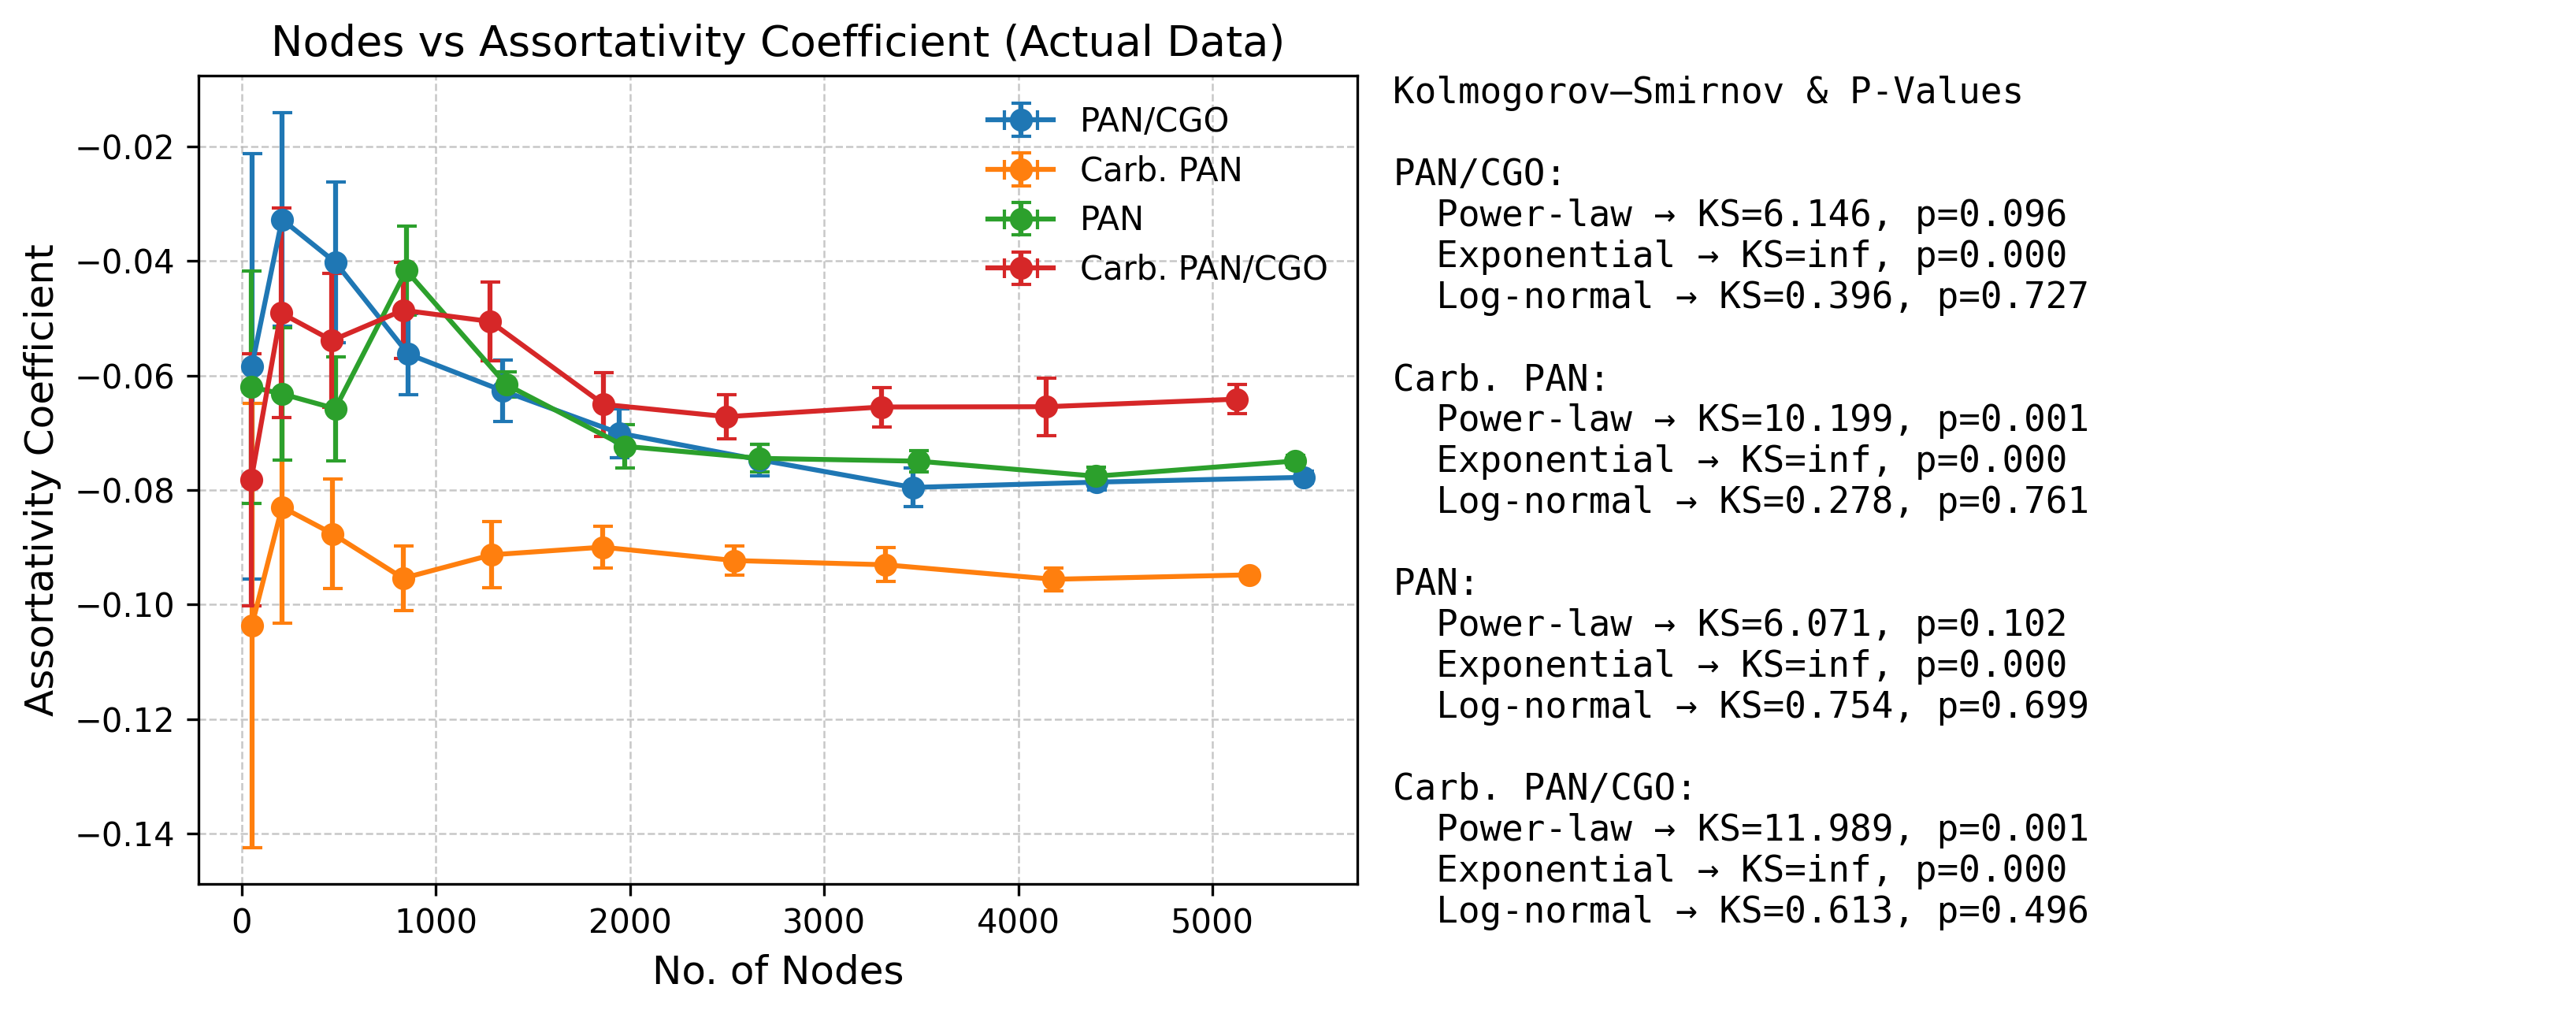

In [13]:
"""
Assortativity Coefficient
"""
df_asc = all_sheets['Nodes-ASC']
plt_fig = sgt_scaling_plot("Assortativity Coefficient", df_asc, material_labels, skip_test=False)
plt_figs.append(plt_fig)

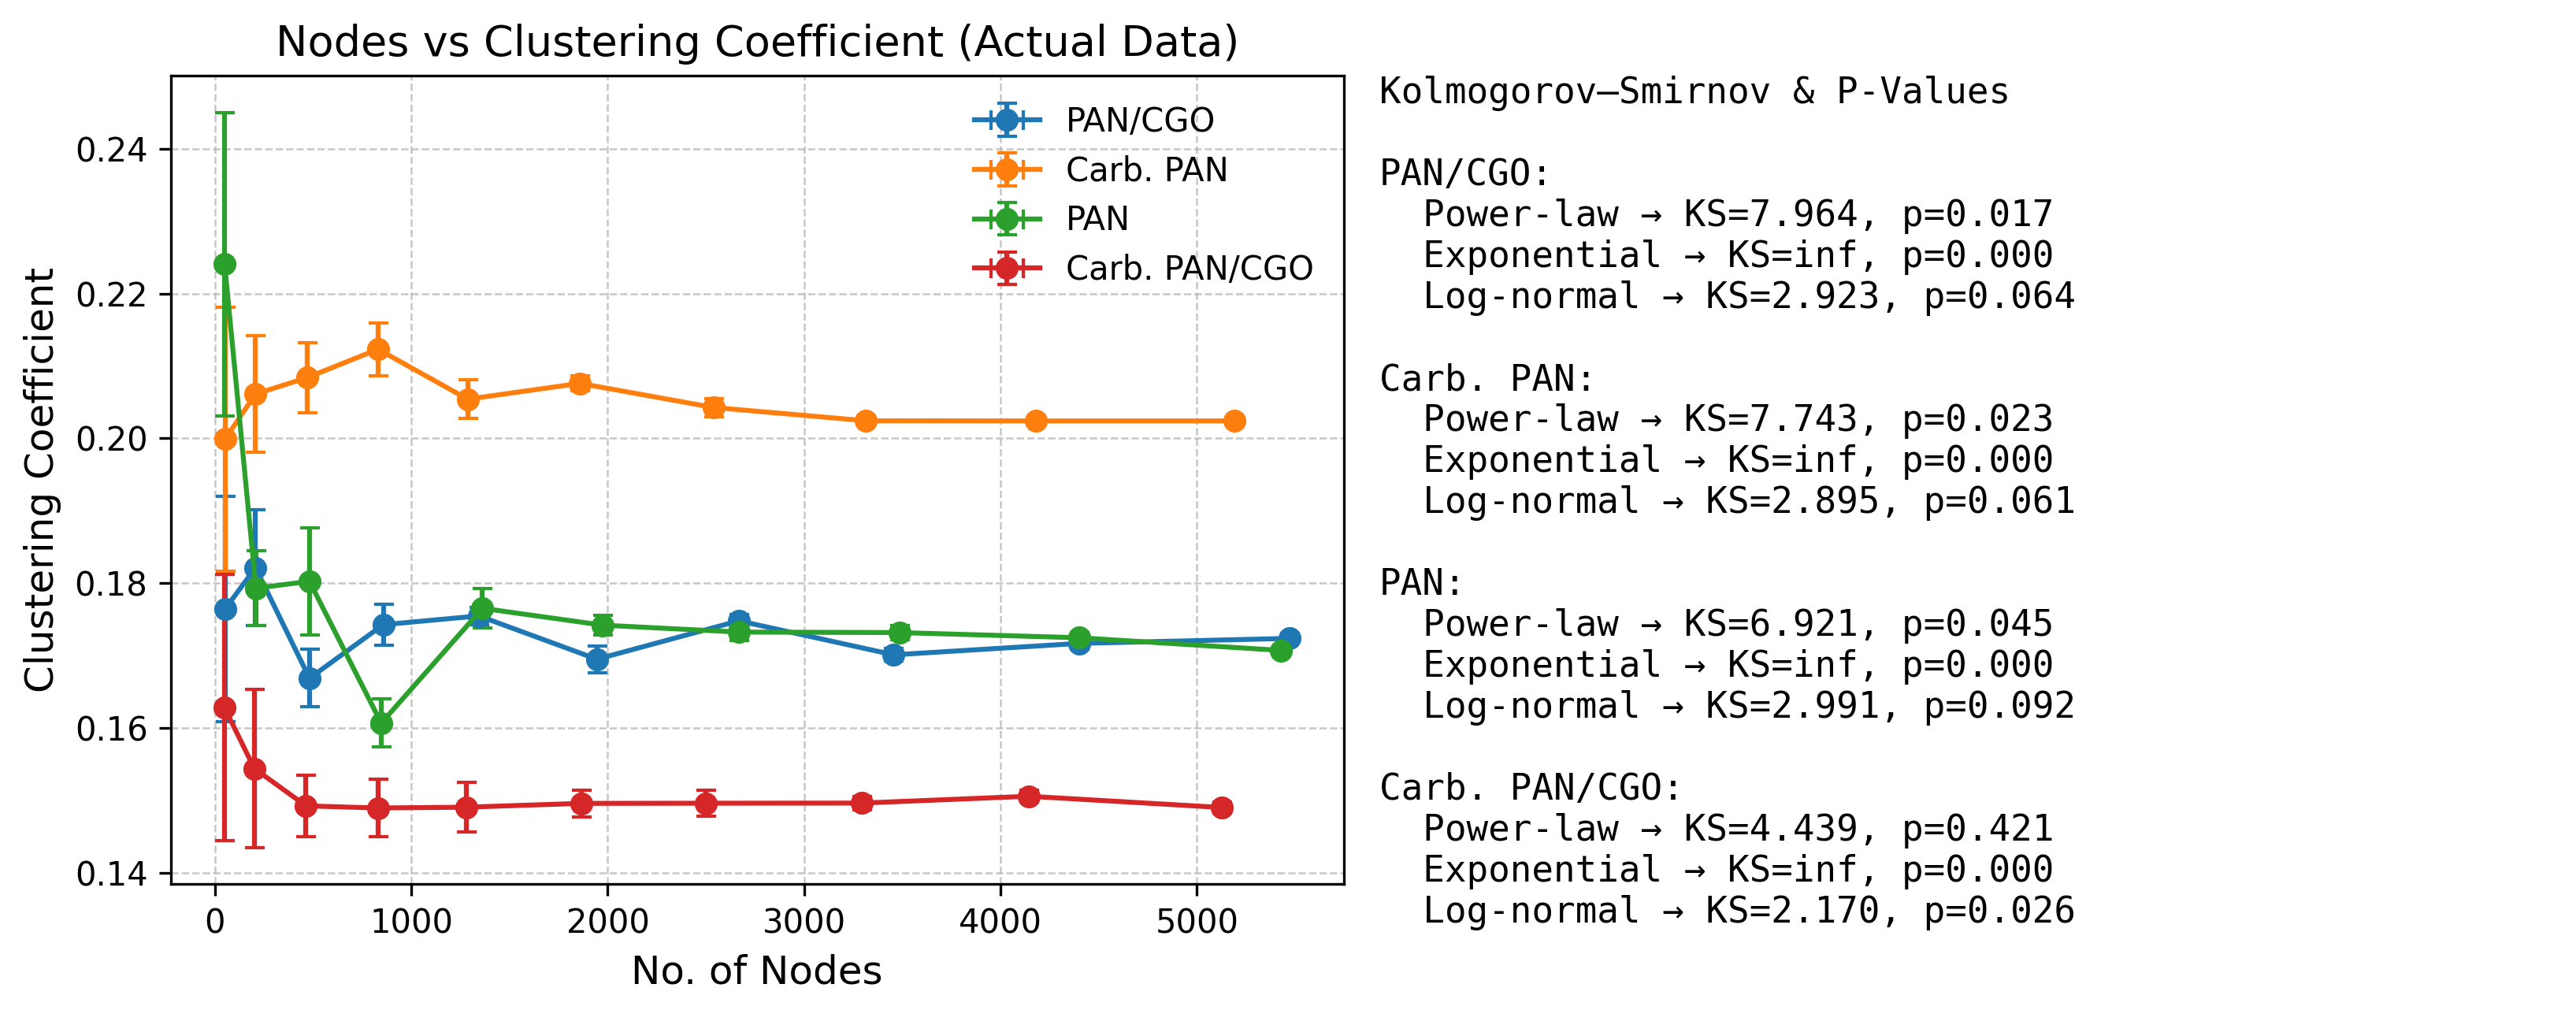

In [14]:
"""
Clustering Coefficient
"""
df_acc = all_sheets['Nodes-ACC']
plt_fig = sgt_scaling_plot("Clustering Coefficient", df_acc, material_labels, skip_test=False)
plt_figs.append(plt_fig)

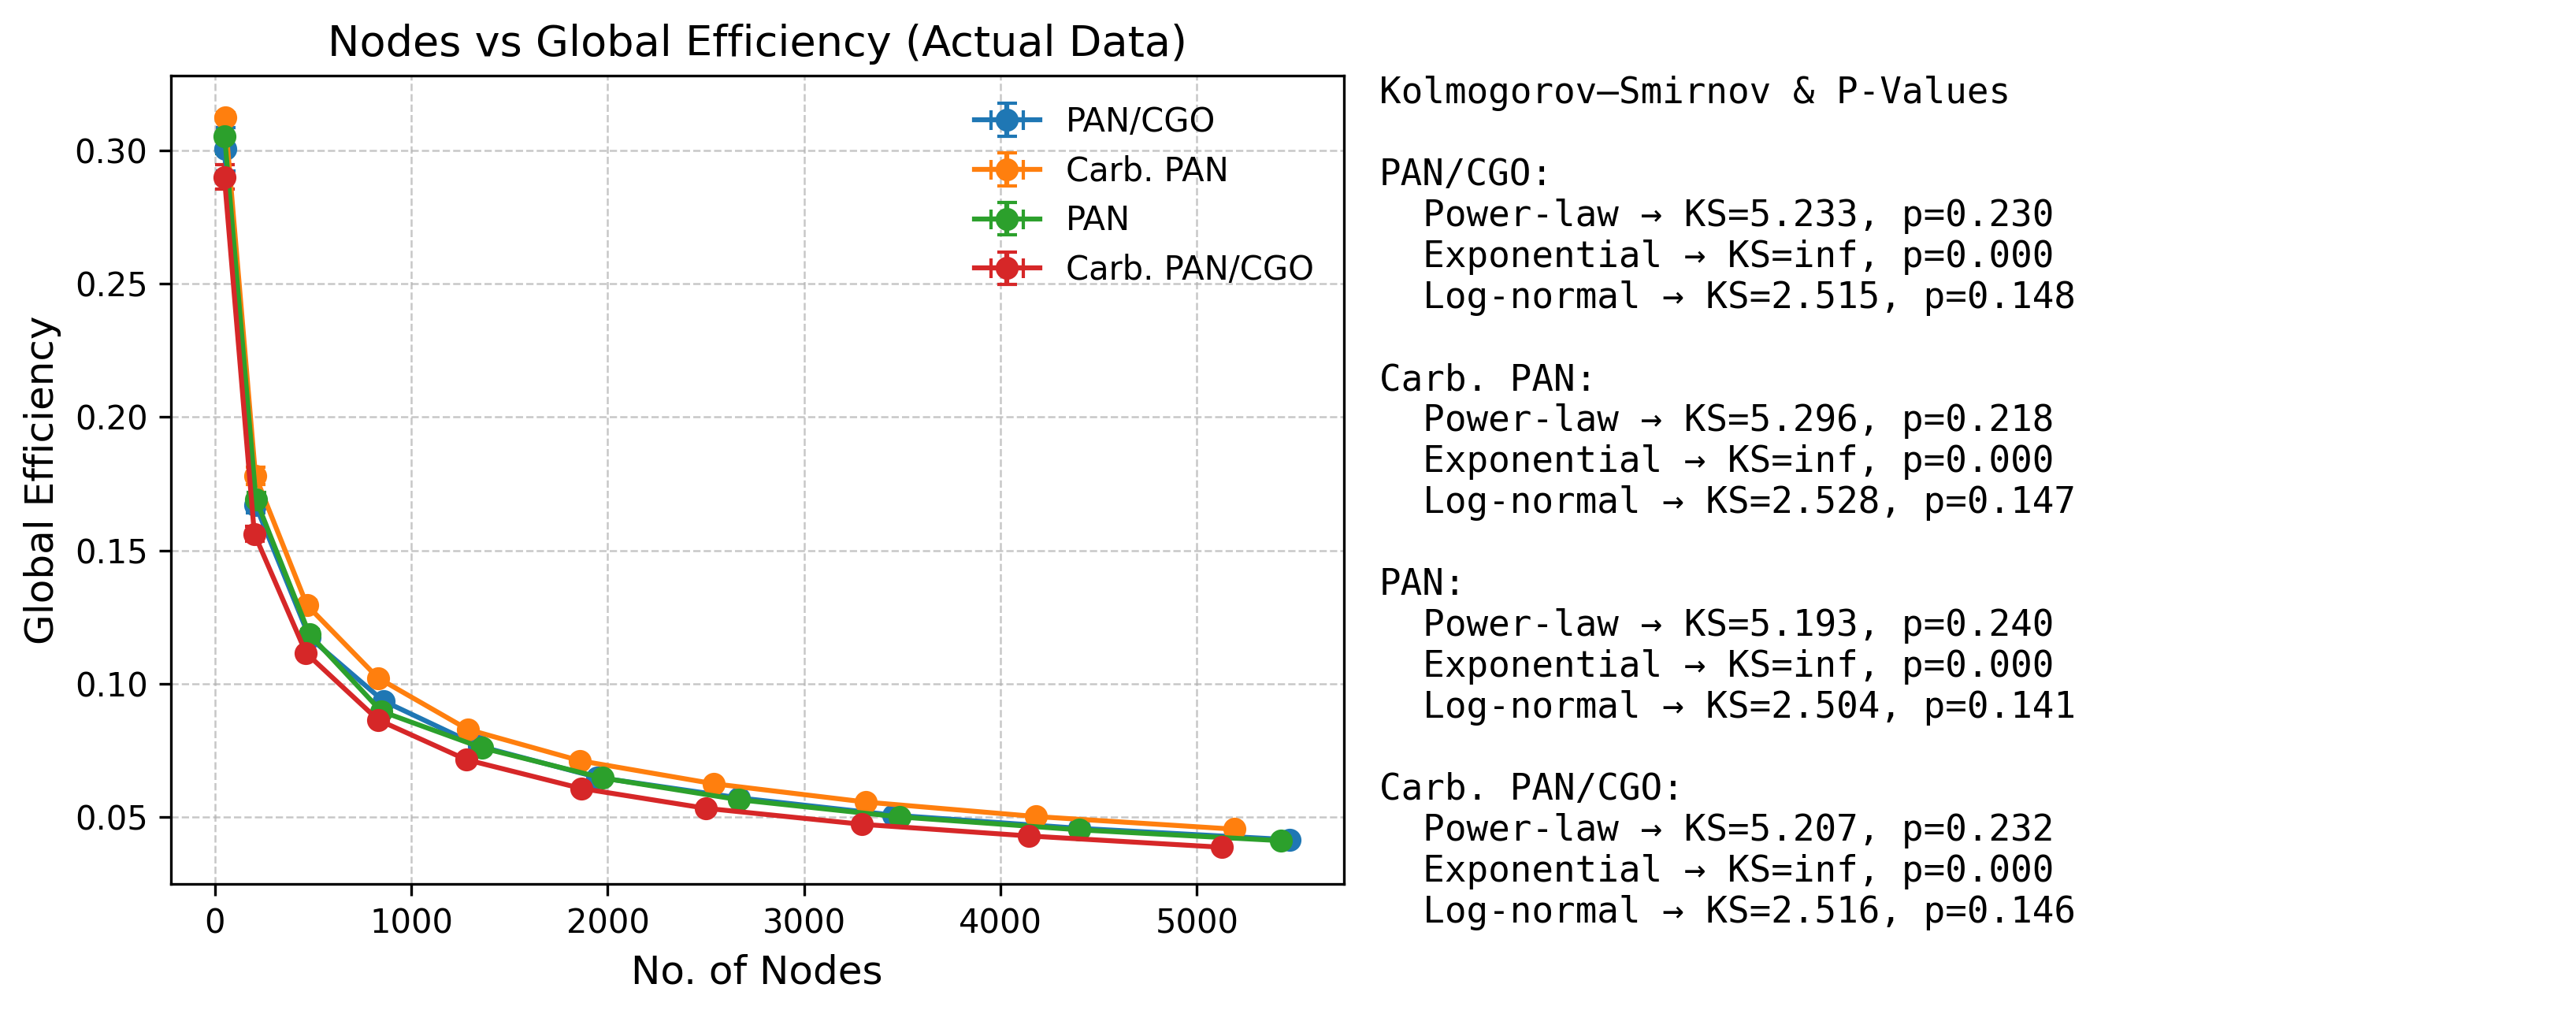

In [15]:
"""
Global Efficiency
"""
df_ge = all_sheets['Nodes-GE']
plt_fig = sgt_scaling_plot("Global Efficiency", df_ge, material_labels, skip_test=False)
plt_figs.append(plt_fig)

In [9]:
with PdfPages(pdf_file) as pdf:
    for fig in plt_figs:
        pdf.savefig(fig)